In [1]:
import json
import re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
RESULTS_DIR = Path("../../data/results/similarity_qed_pubchem")

In [5]:
# Define experiment groups: (model, folder_name)
GROUPS = [
    ("claude-sonnet-4.5", "claude-sonnet-4.5_full_xai"),
    ("claude-opus-4.5", "claude-opus-4.5_full_xai"),
    ("gpt-5.1", "gpt-5.1_full_xai"),
    ("gpt-4.1", "gpt-4.1_full_xai"),
    ("gpt-5.1_reasoning", "gpt-5.1_full_xai_medium"),
    ("gpt-oss-120b", "gpt-oss-120b_full_xai_None"),
]

def load_trace(p):
    """Load trace from JSON file."""
    d = json.loads(p.read_text(encoding="utf-8"))
    return d["trace"] if isinstance(d, dict) and "trace" in d else d

# Load all data into a single DataFrame
rows = []
for model, folder in GROUPS:
    files = sorted((RESULTS_DIR / folder).glob("sim_qed_pubchem_*.json"))
    if not files:
        raise FileNotFoundError(f"No files in {RESULTS_DIR/folder} matching sim_qed_pubchem_*.json")
    
    for file_idx, file_path in enumerate(files):
        # Extract target molecule (e.g., "mol1", "mol2") from filename
        mol_match = re.search(r'mol\d+', file_path.name)
        target_molecule = mol_match.group() if mol_match else f"mol{file_idx}"
        
        trace = load_trace(file_path)
        for entry in trace:
            rows.append({
                "model": model,
                "target_molecule": target_molecule,
                "iteration": int(entry["iteration"]),
                "score": float(entry["score"]),
                "smiles": entry["smiles"],
            })

df = pd.DataFrame(rows)


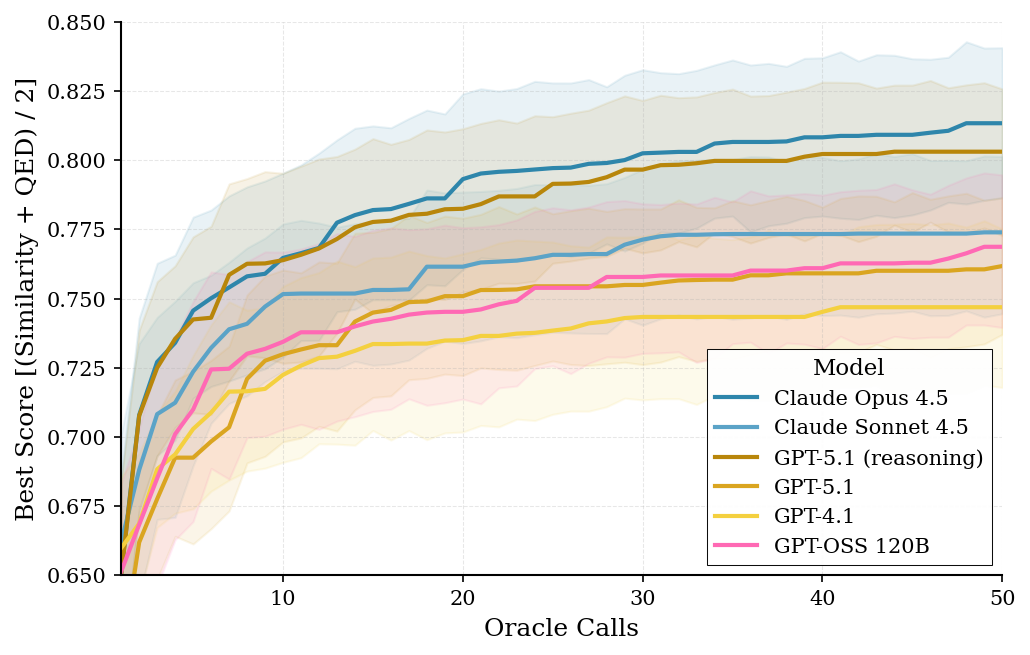

In [9]:
# Compute best-so-far (cummax needs data sorted by iteration)
df["best_so_far"] = (
    df.sort_values("iteration")
    .groupby(["model", "target_molecule"])["score"]
    .cummax()
)

# Pivot so each run is a column, forward-fill to handle runs ending early
max_iter = 50  # Limit to 50 iterations
all_iterations = range(1, max_iter + 1)
df_plot = (
    df[df["iteration"] <= max_iter]
    .pivot_table(index="iteration", columns=["model", "target_molecule"], values="best_so_far")
    .reindex(all_iterations)
    .ffill()
    .melt(ignore_index=False)
    .reset_index()
)

# Set publication-quality style
plt.rcParams.update({
    'font.size': 11,
    'font.family': 'serif',
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.figsize': (6, 4),
    'axes.linewidth': 1.0,
    'grid.linewidth': 0.5,
    'lines.linewidth': 2.0,
})

# Create figure with better proportions
fig, ax = plt.subplots(figsize=(7, 4.5), dpi=150)

# Define color palette and publication names for all models in the data
# All GPT models in purple shades, Claude models in blue shades
unique_models = df_plot['model'].unique()
model_colors = {
    'claude-opus-4.5': '#2E86AB',
    'claude-sonnet-4.5': '#5BA3C7',
    'gpt-4.1': '#F4D03F',           # Lightest yellow (brighter)
    'gpt-5.1': '#DAA520',           # Medium yellow (goldenrod)
    'gpt-5.1_reasoning': '#B8860B',  # Darkest yellow (dark goldenrod)
    'gpt-oss-120b': '#FF69B4',        # pink
}

# Map internal model names to publication-ready names
model_display_names = {
    'claude-opus-4.5': 'Claude Opus 4.5',
    'claude-sonnet-4.5': 'Claude Sonnet 4.5',
    'gpt-4.1': 'GPT-4.1',
    'gpt-5.1': 'GPT-5.1',
    'gpt-5.1_reasoning': 'GPT-5.1 (reasoning)',
    'gpt-oss-120b': 'GPT-OSS 120B',
}

# Define legend order
legend_order = [
    'Claude Opus 4.5',
    'Claude Sonnet 4.5',
    'GPT-5.1 (reasoning)',
    'GPT-5.1',
    'GPT-4.1',
    'GPT-OSS 120B',
]

# Add display names to dataframe
df_plot['model_display'] = df_plot['model'].map(model_display_names)

# Create color palette with display names
display_colors = {model_display_names[k]: v for k, v in model_colors.items() if k in model_display_names}

# Plot with seaborn (mean + 95% bootstrap CI)
sns.lineplot(
    data=df_plot, 
    x="iteration", 
    y="value", 
    hue="model_display",
    hue_order=legend_order,
    palette=display_colors,
    errorbar=('ci', 95),
    err_kws={'alpha': 0.1},  # Make confidence interval more transparent
    linewidth=2.0,
    ax=ax
)

# Styling
ax.set_xlabel("Oracle Calls", fontsize=12, fontweight='normal')
ax.set_ylabel("Best Score [(Similarity + QED) / 2]", fontsize=12, fontweight='normal')
ax.set_xlim(1, 50)
ax.set_ylim(0.65, 0.85)
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Improve legend
legend = ax.legend(
    title='Model',
    frameon=True,
    fancybox=False,
    shadow=False,
    framealpha=0.95,
    edgecolor='black',
    loc='lower right'
)
legend.get_frame().set_linewidth(0.5)

plt.tight_layout()

# Save figure as PDF
plt.savefig('./figures/llm_comparison.pdf', format='pdf', bbox_inches='tight', dpi=300)

plt.show()